In [1]:
import os
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
RAW = os.path.join(PROJECT_ROOT, "data/raw")
PROC = os.path.join(PROJECT_ROOT, "data/processed")
RESULTS_DIR = os.path.join(PROJECT_ROOT, "results")
print("Project root:", PROJECT_ROOT)

Project root: f:\BRACU\CSE425\Project\gnn-bert-music-context


In [ ]:
# ============================================================
# CELL 1 — Setup
# ============================================================
import os, re, json
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from tqdm import tqdm
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import f1_score
from transformers import BertTokenizer, BertModel
from torch.utils.data import TensorDataset, DataLoader
from torch.optim import AdamW


SPLITS_DIR = os.path.join(PROJECT_ROOT, "data/splits")

os.makedirs(SPLITS_DIR, exist_ok=True)
os.makedirs(os.path.join(RESULTS_DIR, "plots"), exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

d:\Program Files\Python\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


In [ ]:
# ============================================================
# CELL 2 — Build text field, split, tokenize 
# ============================================================
mtat_top50 = pd.read_csv(os.path.join(PROC, "mtat_top50_tags.csv"))
mtat_annotations = pd.read_csv(os.path.join(RAW, "mtat_annotations.csv"), sep="\t")
mtat_top50 = mtat_top50.merge(mtat_annotations[["clip_id", "mp3_path"]], on="clip_id", how="left", suffixes=("", "_dup"))
if "mp3_path_dup" in mtat_top50.columns:
    mtat_top50.drop(columns=["mp3_path_dup"], inplace=True)

def clean_filename_to_text(mp3_path):
    name = mp3_path.split("/")[-1].replace(".mp3", "")
    name = re.sub(r'-\d+-\d+$', '', name)
    name = re.sub(r'[-_]+', ' ', name)
    name = re.sub(r'\s+', ' ', name).strip()
    return name

mtat_top50["text"] = mtat_top50["mp3_path"].apply(clean_filename_to_text)

groups = mtat_top50["text"]
gss = GroupShuffleSplit(n_splits=1, train_size=0.8, random_state=42)
train_idx, temp_idx = next(gss.split(mtat_top50, groups=groups))
train_df = mtat_top50.iloc[train_idx].reset_index(drop=True)
temp_df = mtat_top50.iloc[temp_idx].reset_index(drop=True)

gss2 = GroupShuffleSplit(n_splits=1, train_size=0.5, random_state=42)
val_idx, test_idx = next(gss2.split(temp_df, groups=temp_df["text"]))
val_df = temp_df.iloc[val_idx].reset_index(drop=True)
test_df = temp_df.iloc[test_idx].reset_index(drop=True)

print("Train:", len(train_df), "| Val:", len(val_df), "| Test:", len(test_df))

train_df.to_csv(os.path.join(SPLITS_DIR, "mtat_train.csv"), index=False)
val_df.to_csv(os.path.join(SPLITS_DIR, "mtat_val.csv"), index=False)
test_df.to_csv(os.path.join(SPLITS_DIR, "mtat_test.csv"), index=False)

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

def tokenize_split(df, max_length=128):
    tokens = tokenizer(df["text"].tolist(), padding="max_length", truncation=True,
                        max_length=max_length, return_tensors="pt")
    tag_cols = [c for c in df.columns if c not in ["clip_id", "mp3_path", "text"]]
    labels = torch.tensor(df[tag_cols].values, dtype=torch.float)
    return tokens["input_ids"], tokens["attention_mask"], labels, tag_cols

train_ids, train_mask, train_labels, tag_cols = tokenize_split(train_df)
val_ids, val_mask, val_labels, _ = tokenize_split(val_df)
test_ids, test_mask, test_labels, _ = tokenize_split(test_df)
print("Train:", train_ids.shape, train_labels.shape)

Train: 20558 | Val: 2726 | Test: 2579


Train: torch.Size([20558, 128]) torch.Size([20558, 50])


In [ ]:
# ============================================================
# CELL 3 — Model, DataLoaders, training loop
# ============================================================
class BertTagClassifier(nn.Module):
    def __init__(self, num_tags):
        super().__init__()
        self.bert = BertModel.from_pretrained("bert-base-uncased")
        self.classifier = nn.Linear(self.bert.config.hidden_size, num_tags)
    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_embedding = outputs.last_hidden_state[:, 0, :]
        return self.classifier(cls_embedding)

model = BertTagClassifier(num_tags=50).to(device)

BATCH_SIZE = 16  

train_loader = DataLoader(TensorDataset(train_ids, train_mask, train_labels), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TensorDataset(val_ids, val_mask, val_labels), batch_size=BATCH_SIZE)
test_loader = DataLoader(TensorDataset(test_ids, test_mask, test_labels), batch_size=BATCH_SIZE)

criterion = nn.BCEWithLogitsLoss()
optimizer = AdamW(model.parameters(), lr=2e-5)

def evaluate(loader):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0
    with torch.no_grad():
        for input_ids, attn_mask, labels in loader:
            input_ids, attn_mask, labels = input_ids.to(device), attn_mask.to(device), labels.to(device)
            logits = model(input_ids, attn_mask)
            loss = criterion(logits, labels)
            total_loss += loss.item()
            preds = (torch.sigmoid(logits) > 0.5).float()
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    micro_f1 = f1_score(all_labels, all_preds, average="micro", zero_division=0)
    return total_loss / len(loader), macro_f1, micro_f1

history = {"train_loss": [], "val_loss": [], "val_macro_f1": [], "val_micro_f1": []}
EPOCHS = 5

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    for input_ids, attn_mask, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        input_ids, attn_mask, labels = input_ids.to(device), attn_mask.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(input_ids, attn_mask)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    val_loss, val_macro_f1, val_micro_f1 = evaluate(val_loader)
    history["train_loss"].append(train_loss/len(train_loader))
    history["val_loss"].append(val_loss)
    history["val_macro_f1"].append(val_macro_f1)
    history["val_micro_f1"].append(val_micro_f1)
    print(f"Epoch {epoch+1}: train_loss={train_loss/len(train_loader):.4f} | "
          f"val_loss={val_loss:.4f} | val_macro_f1={val_macro_f1:.4f} | val_micro_f1={val_micro_f1:.4f}")

d:\Program Files\Python\Lib\site-packages\huggingface_hub\file_download.py:142: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\zawad\.cache\huggingface\hub\models--bert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7289.60it/s]
[transformers] BertModel LOAD REPORT from: bert-base-uncase

Epoch 1: train_loss=0.1854 | val_loss=0.1433 | val_macro_f1=0.1336 | val_micro_f1=0.2809


Epoch 2: 100%|██████████| 1285/1285 [08:13<00:00,  2.60it/s]


Epoch 2: train_loss=0.1417 | val_loss=0.1368 | val_macro_f1=0.1852 | val_micro_f1=0.3219


Epoch 3: 100%|██████████| 1285/1285 [08:15<00:00,  2.59it/s]


Epoch 3: train_loss=0.1338 | val_loss=0.1350 | val_macro_f1=0.2089 | val_micro_f1=0.3511


Epoch 4: 100%|██████████| 1285/1285 [08:16<00:00,  2.59it/s]


Epoch 4: train_loss=0.1290 | val_loss=0.1348 | val_macro_f1=0.2481 | val_micro_f1=0.3915


Epoch 5: 100%|██████████| 1285/1285 [08:08<00:00,  2.63it/s]


Epoch 5: train_loss=0.1256 | val_loss=0.1331 | val_macro_f1=0.2357 | val_micro_f1=0.3822


TEST: loss=0.1415 | macro_f1=0.2057 | micro_f1=0.3480


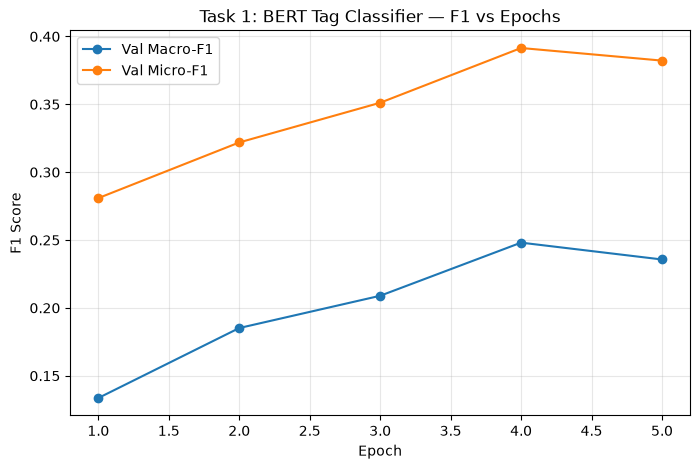

In [4]:
# Test evaluation
test_loss, test_macro_f1, test_micro_f1 = evaluate(test_loader)
print(f"TEST: loss={test_loss:.4f} | macro_f1={test_macro_f1:.4f} | micro_f1={test_micro_f1:.4f}")

# Save model + history
torch.save(model.state_dict(), os.path.join(RESULTS_DIR, "task1_bert_model.pt"))
with open(os.path.join(RESULTS_DIR, "task1_history.json"), "w") as f:
    json.dump(history, f, indent=2)

# F1 vs epoch plot
import matplotlib.pyplot as plt
epochs_range = range(1, len(history["val_macro_f1"]) + 1)
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history["val_macro_f1"], marker='o', label="Val Macro-F1")
plt.plot(epochs_range, history["val_micro_f1"], marker='o', label="Val Micro-F1")
plt.xlabel("Epoch"); plt.ylabel("F1 Score")
plt.title("Task 1: BERT Tag Classifier — F1 vs Epochs")
plt.legend(); plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(RESULTS_DIR, "plots/task1_f1_curve.png"), dpi=150)
plt.show()

In [10]:
from sklearn.metrics import average_precision_score

model.eval()
all_probs, all_labels = [], []
with torch.no_grad():
    for input_ids, attn_mask, labels in test_loader:
        input_ids, attn_mask = input_ids.to(device), attn_mask.to(device)
        probs = torch.sigmoid(model(input_ids, attn_mask)).cpu().numpy()
        all_probs.append(probs)
        all_labels.append(labels.numpy())
all_probs, all_labels = np.concatenate(all_probs), np.concatenate(all_labels)

auc_pr_per_tag = [average_precision_score(all_labels[:, i], all_probs[:, i])
                   if all_labels[:, i].sum() > 0 else np.nan for i in range(50)]
mean_auc_pr = np.nanmean(auc_pr_per_tag)
print("Task 1 mean AUC-PR:", mean_auc_pr)

Task 1 mean AUC-PR: 0.32924869553662683


In [6]:
# 5 example predictions
model.eval()
sample_indices = np.random.choice(len(test_df), 5, replace=False)
for idx in sample_indices:
    row = test_df.iloc[idx]
    input_ids = test_ids[idx].unsqueeze(0).to(device)
    attn_mask = test_mask[idx].unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(input_ids, attn_mask)
        probs = torch.sigmoid(logits).cpu().numpy()[0]
    true_tags = [tag_cols[i] for i in range(50) if row[tag_cols[i]] == 1]
    pred_tags = [tag_cols[i] for i in range(50) if probs[i] > 0.5]
    print(f"Text: {row['text']}")
    print(f"True: {true_tags}")
    print(f"Pred: {pred_tags}")
    print("-" * 60)

Text: edward martin art of the lute in renaissance france 01 prelude phalese
True: ['guitar', 'slow', 'harp']
Pred: ['guitar']
------------------------------------------------------------
Text: indidginus seismic 06 semonkong place of smoke
True: ['singing', 'vocals']
Pred: ['techno', 'electronic']
------------------------------------------------------------
Text: hoxman synthesis of five 11 nighty girl
True: []
Pred: []
------------------------------------------------------------
Text: cargo cult alchemy 11 garden
True: ['electronic']
Pred: ['techno', 'electronic']
------------------------------------------------------------
Text: artemis orbits 10 charming gun the charmed mix erik hawk and bo blount
True: ['techno', 'electronic', 'female', 'singing', 'vocals', 'woman', 'pop', 'female voice']
Pred: ['female']
------------------------------------------------------------


In [7]:
import json

model.eval()
sample_indices = np.random.choice(len(test_df), 5, replace=False)
example_predictions = []

for idx in sample_indices:
    row = test_df.iloc[idx]
    input_ids = test_ids[idx].unsqueeze(0).to(device)
    attn_mask = test_mask[idx].unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(input_ids, attn_mask)
        probs = torch.sigmoid(logits).cpu().numpy()[0]

    true_tags = [tag_cols[i] for i in range(50) if row[tag_cols[i]] == 1]
    pred_tags = [tag_cols[i] for i in range(50) if probs[i] > 0.5]

    example_predictions.append({
        "text": row["text"],
        "true_tags": true_tags,
        "predicted_tags": pred_tags
    })

with open(os.path.join(RESULTS_DIR, "task1_example_predictions.json"), "w") as f:
    json.dump(example_predictions, f, indent=2)

print("Saved 5 example predictions.")

Saved 5 example predictions.
